# B4B jeepney RL final model
This notebook trains the final PPO policy, saves the model, and compares route performance before and after learning using the same passenger evaluation stack.


## 1. Shared geometric seed routes
We keep the same physical-graph generator here so the learned policy is judged against the same starting geometry.


In [1]:

import math
import secrets
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, IFrame, display
from shapely.geometry import Polygon
from tqdm.auto import tqdm

from _bootstrap import ROOT
from utils import (
    BaselineRoute,
    BaselineRouteGenerator,
    JeepneyRouteEnv,
    JeepneySystem,
    SystemicFitnessEvaluator,
    build_route_notes as build_route_spectrum_notes,
    build_route_spectrum_frame,
    calculate_route_fitness,
    compare_route_spectrum_frames,
    make_coord_key,
    plot_correlation_delta,
    plot_correlation_heatmap,
    route_correlation_pairs,
    route_spectrum_correlation,
    summarize_route_spectrum,
    train_route_agent,
)

OUTPUT_DIR = Path(ROOT) / "results" / "B4A_jeepney_rl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_ROUTES = 20
random_seed = secrets.randbits(32)

generator = BaselineRouteGenerator(
    min_area_m2=2_000_000,
    anchor_pool_size=96,
    max_attempts=500,
    seed=random_seed,
)
routes = generator.generate_routes(NUM_ROUTES, route_prefix="B4A", seed=random_seed)
route_system = JeepneySystem.from_routes(routes)
summary = pd.DataFrame(
    [
        {
            "route_id": route.route_id,
            "anchors": list(route.ordered_anchor_node_ids),
            "area_m2": round(route.polygon_area_m2, 0),
            "length_m": round(route.path_length_m, 0),
            "attempt": route.attempt_index,
        }
        for route in routes
    ]
)
summary.to_csv(OUTPUT_DIR / "B4A_pre_training_routes.csv", index=False)

def get_systemic_fitness(route: BaselineRoute, *, use_full: bool = True, seed_offset: int = 0, batch_size: int = 8):
    return calculate_route_fitness(
        route.path_node_ids,
        passenger_map=generator.passenger_map,
        drive_graph_raw=generator.drive_graph_raw,
        drive_graph_proj=generator.drive_graph_proj,
        seed=random_seed + seed_offset,
        batch_size=batch_size,
    )

summary

node_latlon_lookup = {
    int(row.base_node_id): (float(row.lat), float(row.lon))
    for row in generator.node_table.itertuples(index=False)
}

def _route_latlon(route_node_ids: list[int]) -> list[tuple[float, float]]:
    return [node_latlon_lookup[int(node_id)] for node_id in route_node_ids if int(node_id) in node_latlon_lookup]

def _route_length_m(route_node_ids: list[int]) -> float:
    total = 0.0
    for start_node, end_node in zip(route_node_ids[:-1], route_node_ids[1:]):
        edge_data = generator.drive_graph_raw.get_edge_data(int(start_node), int(end_node), default=None)
        if edge_data:
            lengths = [float(data.get('length', 0.0)) for data in edge_data.values() if isinstance(data, dict)]
            if lengths:
                total += min(lengths)
                continue
        start_latlon = node_latlon_lookup.get(int(start_node))
        end_latlon = node_latlon_lookup.get(int(end_node))
        if start_latlon is None or end_latlon is None:
            continue
        total += math.hypot(end_latlon[0] - start_latlon[0], end_latlon[1] - start_latlon[1]) * 111_000.0
    return float(total)

def _pad_anchor_ids(route_node_ids: list[int]) -> tuple[int, int, int, int]:
    anchors = [int(node_id) for node_id in route_node_ids[:4]]
    if not anchors:
        return tuple()
    while len(anchors) < 4:
        anchors.append(anchors[-1])
    return tuple(anchors[:4])

def collect_policy_routes(model, *, route_count: int, label_prefix: str = 'POST', seed_offset: int = 0):
    routes: list[SimpleNamespace] = []
    for route_index in range(route_count):
        route_seed = random_seed + seed_offset + route_index
        env = JeepneyRouteEnv(
            drive_graph_raw=generator.drive_graph_raw,
            drive_graph_proj=generator.drive_graph_proj,
            passenger_map=generator.passenger_map,
            seed=route_seed,
            max_steps=64,
            min_route_nodes=6,
        )
        obs, info = env.reset(seed=route_seed)
        terminated = truncated = False
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
        route_node_ids = [int(node_id) for node_id in info.get('route_path_node_ids', env.path_node_ids)]
        route_latlon = _route_latlon(route_node_ids)
        routes.append(
            SimpleNamespace(
                route_id=f'{label_prefix}{route_index + 1:02d}',
                path_node_ids=route_node_ids,
                path_latlon=route_latlon,
                path_length_m=_route_length_m(route_node_ids),
                polygon_area_m2=float(Polygon(route_latlon).area) if len(route_latlon) >= 3 else 0.0,
                ordered_anchor_node_ids=_pad_anchor_ids(route_node_ids),
            )
        )
    return routes

def plot_training_curve(history: list[dict[str, object]], output_png: Path) -> Path:
    frame = pd.DataFrame(history)
    if frame.empty:
        raise ValueError('No training history was captured.')
    frame = frame.sort_values('episode_index')
    window = min(25, max(len(frame), 1))
    frame['rolling_return'] = frame['episode_return'].rolling(window=window, min_periods=1).mean()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(frame['episode_index'], frame['episode_return'], color='#93c5fd', alpha=0.35, linewidth=1, label='episode return')
    ax.plot(frame['episode_index'], frame['rolling_return'], color='#1d4ed8', linewidth=2, label=f'{window}-episode rolling mean')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Return')
    ax.set_title('B4B PPO training curve')
    ax.legend()
    ax.grid(True, alpha=0.2)
    output_png.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(output_png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return output_png


c:\Users\lifei\OneDrive\Desktop\Thesis\Thesis Repository\Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,route_id,anchors,area_m2,length_m,attempt
0,B4A01,"[867, 39, 486, 367]",8741589.0,32213.0,1
1,B4A02,"[110, 836, 2803, 1090]",71729231.0,61711.0,1
2,B4A03,"[2900, 210, 178, 519]",55719076.0,62247.0,1
3,B4A04,"[2648, 35, 492, 180]",41097742.0,54628.0,1
4,B4A05,"[1683, 1383, 737, 1184]",6004768.0,16820.0,1
5,B4A06,"[105, 1576, 999, 1090]",43434303.0,47814.0,1
6,B4A07,"[3122, 476, 808, 1722]",9816788.0,42329.0,1
7,B4A08,"[1090, 1190, 2560, 106]",32398498.0,41958.0,1
8,B4A09,"[210, 2919, 96, 617]",125931611.0,92079.0,1
9,B4A10,"[683, 1569, 2356, 1090]",38008432.0,38471.0,1


## 2. RL environment and state embeddings
This is a quick sanity check on the coordinate-relative observation space the policy will see.


In [2]:

np.set_printoptions(precision=3, suppress=True)
env = JeepneyRouteEnv(
    drive_graph_raw=generator.drive_graph_raw,
    drive_graph_proj=generator.drive_graph_proj,
    seed=random_seed,
    max_steps=12,
)

def print_observation(obs: dict[str, np.ndarray]) -> None:
    print('shape:', obs['shape'])
    print('history:', obs['history'])
    print('topology:', obs['topology'])
    print('demand:', obs['demand'])
    print('global:', obs['global'])
    print('candidates:')
    for candidate_index, row in enumerate(obs['candidates']):
        print(f'  {candidate_index}: {row}')
    print('mask:', obs['action_mask'])

obs, info = env.reset()
print('reset state vector length:', info['state_vector'].shape[0])
print_observation(obs)

rng = np.random.default_rng(random_seed)
for step_index in range(5):
    valid_actions = np.flatnonzero(obs['action_mask'][:-1])
    action = int(rng.choice(valid_actions)) if len(valid_actions) else env.max_candidates
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"step {step_index + 1}: action={action}, reward={reward:.3f}, terminated={terminated}, truncated={truncated}")
    print('turn angle rad:', info['turn_angle_rad'])
    print('sinuosity index:', info['sinuosity_index'])
    print('distance to origin m:', info['distance_to_origin_m'])
    print('bearing to origin rad:', info['bearing_to_origin_rad'])
    print('route area m2:', info['route_area_m2'])
    print('state vector:', info['state_vector'])
    print_observation(obs)
    if terminated or truncated:
        break


reset state vector length: 91
shape: [0. 0. 1. 0. 0. 0. 0.]
history: [0. 0. 0. 0. 0. 0. 0. 0.]
topology: [0.5   0.5   0.    0.5   0.444]
demand: [0.218 0.218 0.235 0.017]
global: [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.5   0.5   0.    0.5   0.444 0.218 0.218 0.235 0.017]
candidates:
  0: [-0.008  1.     0.017  0.5    0.     0.2   -0.018  0.     0.     0.   ]
  1: [0.997 0.079 0.007 0.5   0.    0.235 0.017 0.    0.    0.   ]
  2: [ 0.013 -1.     0.012  0.333  0.     0.218 -0.     0.     1.     0.   ]
  3: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  4: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  5: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
mask: [1. 1. 1. 0. 0. 0. 1.]
step 1: action=1, reward=-0.000, terminated=False, truncated=False
turn angle rad: 0.0
sinuosity index: 1.0
distance to origin m: 50.944496187519896
bearing to origin rad: 3.141592653589793
route area m2: 0.0
state vector: [ 0.001  0.    -1.     0.001  0.001  0.     0.     0.     0.     0.
  0.     1.  

## 3. Reward signal on the layered graph
The route score still comes from passenger generalized travel cost on the 3-layer evaluation graph.


C:\Users\lifei\OneDrive\Desktop\Thesis\Thesis Repository\Thesis\results\B4A_jeepney_rl\B4B_pre_training_route_explorer.html


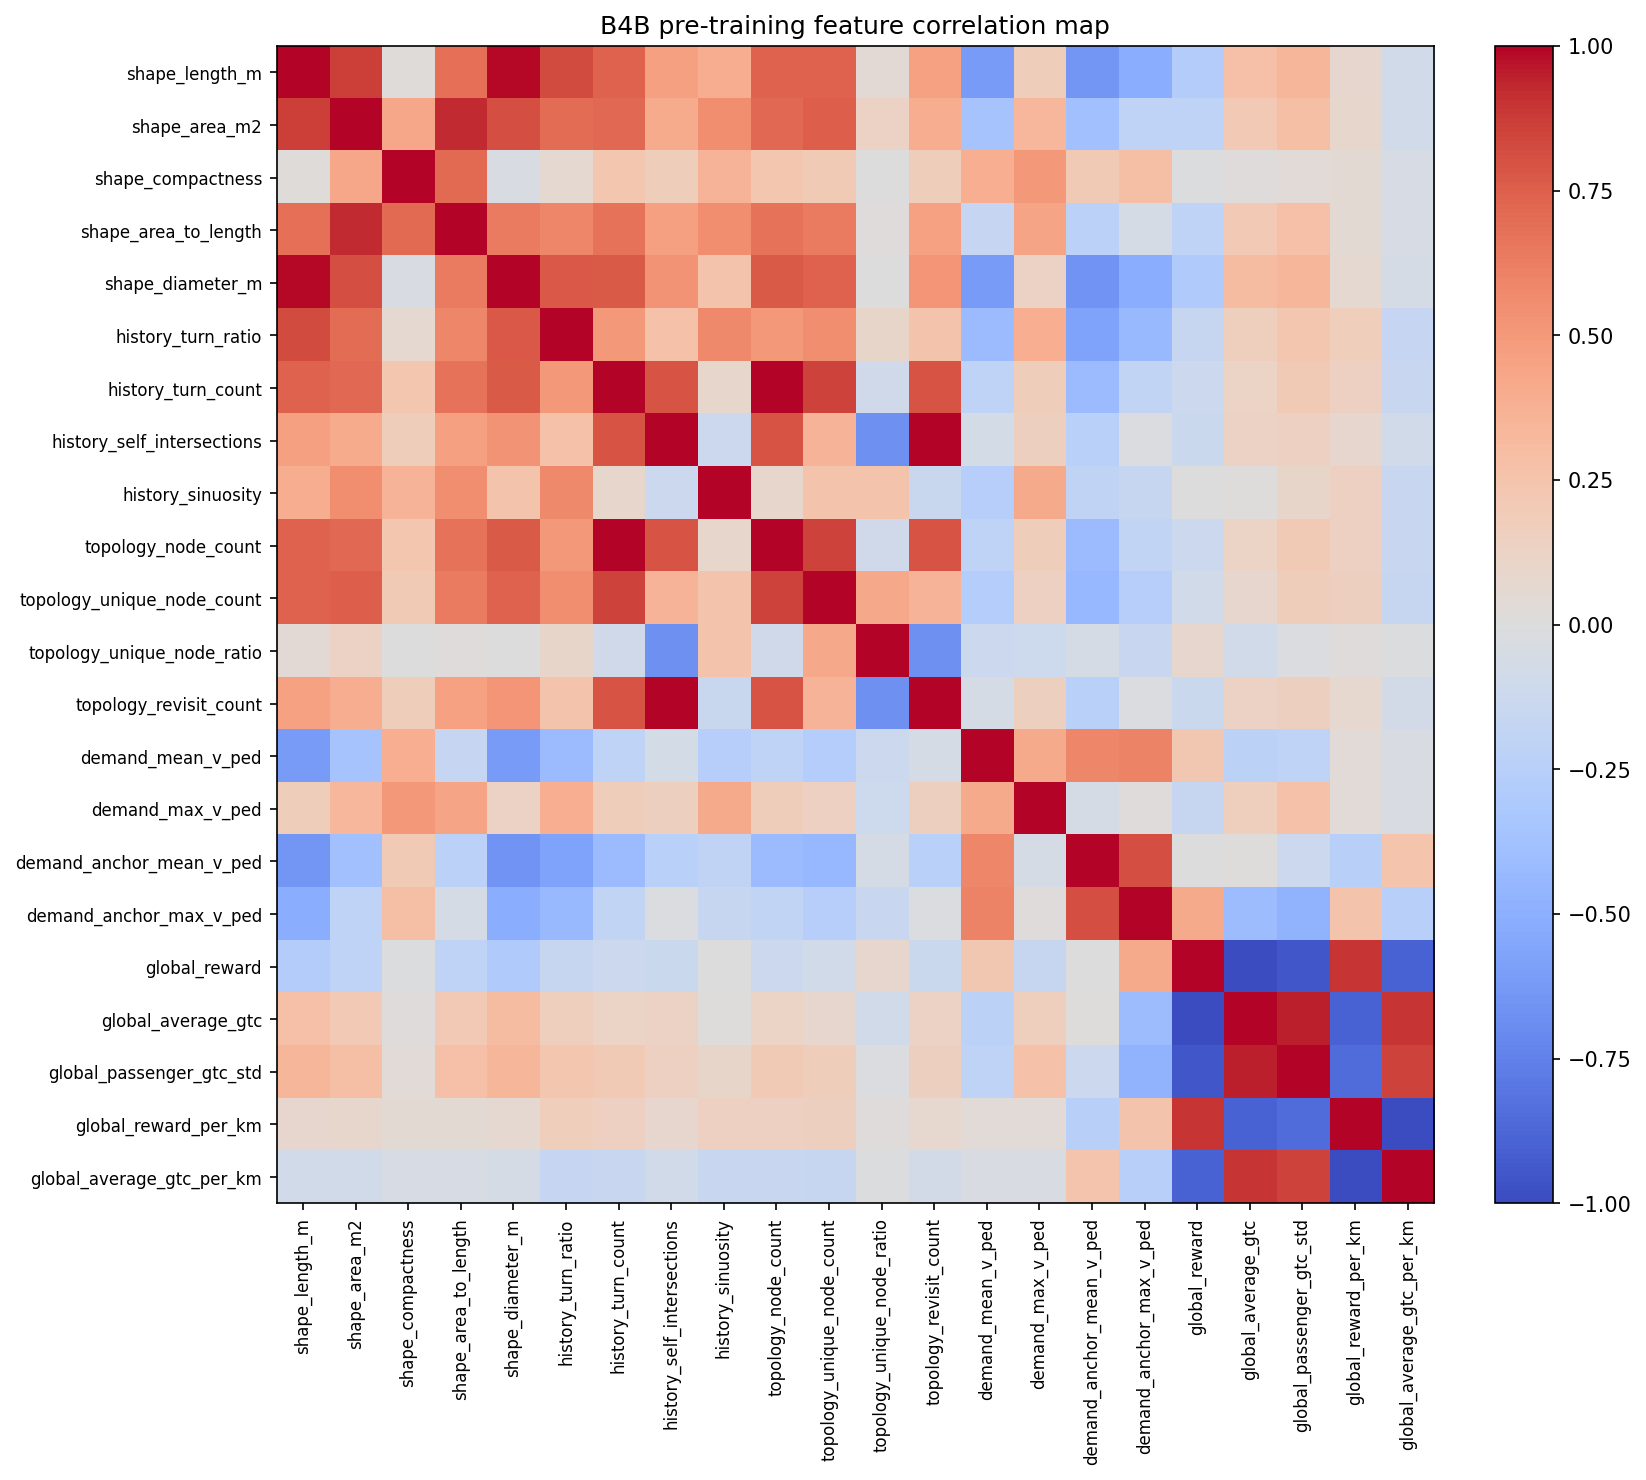

,feature_a,feature_b,correlation
0,history_turn_count,topology_node_count,1.000000
1,global_reward_per_km,global_average_gtc_per_km,-1.000000
2,global_reward,global_average_gtc,-1.000000
3,history_self_intersections,topology_revisit_count,0.999420
4,shape_length_m,shape_diameter_m,0.988045
5,global_reward,global_passenger_gtc_std,-0.949719
6,global_average_gtc,global_passenger_gtc_std,0.949719
7,shape_area_m2,shape_area_to_length,0.922332
8,global_average_gtc,global_average_gtc_per_km,0.897641
9,global_reward,global_average_gtc_per_km,-0.897641


B4B pre-training: 20 routes
means | reward=-7896.141, avg_gtc=7896.141, gtc_std=14098.669, length_m=52983.7, area_m2=44981473.8
spread | reward_std=6318.878, avg_gtc_std=6318.878, sinuosity_mean=2.637, demand_mean=1.701
top | global_reward: global_average_gtc (-1.00), global_passenger_gtc_std (-0.95), global_reward_per_km (+0.90)
top | global_average_gtc: global_reward (-1.00), global_passenger_gtc_std (+0.95), global_reward_per_km (-0.90)
top | global_passenger_gtc_std: global_reward (-0.95), global_average_gtc (+0.95), global_reward_per_km (-0.85)


In [3]:

route_edges = pd.DataFrame(
    [(int(u), int(v), 'start_walk') for u, v in generator.drive_graph_raw.edges()],
    columns=['u', 'v', 'edge_type'],
)
route_manager = SimpleNamespace(
    edges=route_edges,
    _node_coords={
        int(row.base_node_id): (float(row.lat), float(row.lon))
        for row in generator.node_table.itertuples(index=False)
    },
)
raw_latlon_by_node = {
    int(node_id): (float(data.get('y', 0.0)), float(data.get('x', 0.0)))
    for node_id, data in generator.drive_graph_raw.nodes(data=True)
}
proj_xy_by_node = {
    int(node_id): (float(data.get('x', 0.0)), float(data.get('y', 0.0)))
    for node_id, data in generator.drive_graph_proj.nodes(data=True)
}


def build_route_encoding(route_id: str) -> str:
    return f'route_id: {route_id}'


def interpret_embeddings(route: BaselineRoute) -> str:
    route_path = route.path_node_ids
    if not route_path or len(route_path) < 2:
        return 'Route too short to analyze.'

    lines: list[str] = []
    area = route.polygon_area_m2
    length = route.path_length_m
    area_to_length = area / max(length, 1.0)

    if area_to_length > 1000:
        lines.append('shape: Compact, efficient use of space')
    elif area_to_length > 200:
        lines.append('shape: Moderate coverage relative to distance')
    else:
        lines.append('shape: Linear route with extended length')

    node_count = len(route_path)
    if node_count > 50:
        lines.append('topology: High node density, complex route structure')
    elif node_count > 25:
        lines.append('topology: Moderate complexity with multiple waypoints')
    else:
        lines.append('topology: Simple, direct route path')

    if area > 50_000_000:
        lines.append('demand: Large service area, potentially high demand coverage')
    elif area > 10_000_000:
        lines.append('demand: Medium service area with moderate demand potential')
    else:
        lines.append('demand: Compact service area with focused demand')

    if len(route.path_latlon) >= 2:
        start = route.path_latlon[0]
        end = route.path_latlon[-1]
        straight_dist = math.sqrt((end[0] - start[0]) ** 2 + (end[1] - start[1]) ** 2) * 111000
        sinuosity = length / max(straight_dist, 1.0)
        if sinuosity > 1.5:
            lines.append('history: Winding route with many turns')
        elif sinuosity > 1.1:
            lines.append('history: Moderate turning pattern')
        else:
            lines.append('history: Direct path with minimal deviations')

    return '\n'.join(lines) if lines else 'No embedding data available.'


def route_signature(route: BaselineRoute) -> tuple[int, ...]:
    return tuple(int(node_id) for node_id in route.path_node_ids)


def route_notes(route: BaselineRoute, fitness, tag: str) -> dict[str, str]:
    return {
        'encoding': build_route_encoding(route.route_id),
        'interpretation': (
            f'{tag} reward={fitness.reward:.3f} | avg_gtc={fitness.average_gtc:.3f} | ' +
            f'gtc_std={fitness.passenger_gtc_std:.3f}\n\n{interpret_embeddings(route)}'
        ),
    }

def score_route(route: BaselineRoute, *, seed_offset: int = 0, batch_size: int = 5):
    return calculate_route_fitness(
        route.path_node_ids,
        passenger_map=generator.passenger_map,
        drive_graph_raw=generator.drive_graph_raw,
        drive_graph_proj=generator.drive_graph_proj,
        seed=random_seed + seed_offset,
        batch_size=batch_size,
    )


def build_route_metrics(routes: list[BaselineRoute], *, label: str, batch_size: int = 5) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for index, route in enumerate(tqdm(routes, desc=f'Scoring {label} routes')):
        fitness = score_route(route, seed_offset=index, batch_size=batch_size)
        rows.append(
            {
                'route_id': route.route_id,
                'reward': round(float(fitness.reward), 3),
                'average_gtc': round(float(fitness.average_gtc), 3),
                'std_gtc': round(float(fitness.passenger_gtc_std), 3),
                'route_length_m': round(float(route.path_length_m), 3),
                'route_area_m2': round(float(route.polygon_area_m2), 3),
                'node_count': len(route.path_node_ids),
            }
        )
    return pd.DataFrame(rows)


def export_route_spectrum(routes: list[BaselineRoute], metrics: pd.DataFrame, *, output_html: Path, title: str, tag: str) -> Path:
    route_lookup = {route.route_id: route for route in routes}
    notes = {
        row.route_id: route_notes(route_lookup[row.route_id], score_route(route_lookup[row.route_id], seed_offset=i), tag)
        for i, row in enumerate(metrics.itertuples(index=False))
    }
    html_path = route_system.export_route_toggle_html(route_manager, output_html, title=title, route_notes=notes)
    return html_path


def plot_route_spectrum(pre_df: pd.DataFrame, post_df: pd.DataFrame, output_png: Path, *, title: str) -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].scatter(pre_df['average_gtc'], pre_df['std_gtc'], label='pre', alpha=0.75, s=35)
    axes[0].scatter(post_df['average_gtc'], post_df['std_gtc'], label='post', alpha=0.75, s=35)
    axes[0].set_xlabel('Average GTC')
    axes[0].set_ylabel('Passenger GTC std')
    axes[0].set_title('GTC vs stability')
    axes[0].legend()

    axes[1].hist(pre_df['reward'], bins=10, alpha=0.6, label='pre')
    axes[1].hist(post_df['reward'], bins=10, alpha=0.6, label='post')
    axes[1].set_xlabel('Reward')
    axes[1].set_ylabel('Count')
    axes[1].set_title(title)
    axes[1].legend()

    output_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return output_png

passenger_vped_lookup = generator.passenger_map.df.copy()
passenger_vped_lookup["coord_key"] = make_coord_key(passenger_vped_lookup, "lon", "lat")
passenger_vped_lookup = passenger_vped_lookup.groupby("coord_key")["v_ped"].mean().astype(float).to_dict()
node_vped_lookup = {
    int(row.base_node_id): float(passenger_vped_lookup.get(row.coord_key, 0.0))
    for row in generator.node_table.itertuples(index=False)
}

pre_frame = build_route_spectrum_frame(
    routes,
    score_route_fn=lambda route, index: get_systemic_fitness(route, use_full=True, seed_offset=index),
    node_vped_lookup=node_vped_lookup,
    phase='B4B pre-training',
)
pre_summary = summarize_route_spectrum(pre_frame, label='B4B pre-training')
pre_corr = route_spectrum_correlation(pre_frame)
pre_corr_pairs = route_correlation_pairs(pre_corr, limit=12, min_abs=0.35)
pre_route_notes = build_route_spectrum_notes(routes, pre_frame, phase='B4B pre-training')
pre_frame.to_csv(OUTPUT_DIR / 'B4B_pre_training_feature_frame.csv', index=False)
pre_corr.to_csv(OUTPUT_DIR / 'B4B_pre_training_correlations.csv')
pre_corr_png = plot_correlation_heatmap(
    pre_corr,
    OUTPUT_DIR / 'B4B_pre_training_correlation_heatmap.png',
    title='B4B pre-training feature correlation map',
)
pre_html = route_system.export_route_toggle_html(
    route_manager,
    OUTPUT_DIR / 'B4B_pre_training_route_explorer.html',
    title=f'B4B Pre-training Routes ({NUM_ROUTES})',
    route_notes=pre_route_notes,
    overall_summary=pre_summary,
)
print(pre_html)
display(IFrame(pre_html.as_uri(), width=1200, height=900))
display(Image(filename=str(pre_corr_png)))
display(pre_corr_pairs)
print(pre_summary)


## 4. Pre-training correlation spectrum
We score the baseline routes, map the feature relationships, and keep the route explorer focused on the overall findings.


In [4]:
# Legacy duplicate training cell intentionally left blank.
# The real PPO training run is in the later final training cell.
pass


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 6        |
|    ep_rew_mean     | -309     |
| time/              |          |
|    fps             | 12       |
|    iterations      | 1        |
|    time_elapsed    | 80       |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 6.35        |
|    ep_rew_mean          | -256        |
| time/                   |             |
|    fps                  | 9           |
|    iterations           | 2           |
|    time_elapsed         | 204         |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.001672542 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.95       |
|    explained_variance   | -4.22e-05   |
|    learning

## 5. Final PPO training loop
This is the actual model run. We save the trained policy so the notebook leaves behind a reusable artifact.


In [5]:
TRAIN_OUTPUT_DIR = OUTPUT_DIR / 'ppo_training'
training_artifacts = train_route_agent(
    passenger_map=generator.passenger_map,
    drive_graph_raw=generator.drive_graph_raw,
    drive_graph_proj=generator.drive_graph_proj,
    output_dir=TRAIN_OUTPUT_DIR,
    seed=random_seed,
    total_timesteps=250000,
    systemic_test_mean=8,
    systemic_test_std=3,
    background_route_mean=3,
    background_route_std=1,
    systemic_batch_size=16,
    systemic_std_penalty_weight=1.0,  # Deep RL for Transit Network Design: https://arxiv.org/abs/2502.17758
    ppo_kwargs={
        'n_steps': 1024,
        'batch_size': 128,
        'learning_rate': 2.5e-4,
        'gamma': 0.99,
        'ent_coef': 0.01,
        'verbose': 1,
    },
    env_kwargs={
        'max_steps': 64,
        'min_route_nodes': 6,
    },
)
final_model_path = TRAIN_OUTPUT_DIR / 'ppo_final_model'
training_artifacts.model.save(str(final_model_path))
print(f'Training complete. Best episode return: {training_artifacts.best_snapshot.episode_return:.3f}' if training_artifacts.best_snapshot else 'Training complete. No closed-loop route was captured.')
print(f'Worst episode return: {training_artifacts.worst_snapshot.episode_return:.3f}' if training_artifacts.worst_snapshot else 'No worst-route snapshot was captured.')
print(training_artifacts.history_csv)
print(training_artifacts.snapshot_csv)
print(final_model_path)
if training_artifacts.best_snapshot is not None:
    display(IFrame(training_artifacts.best_snapshot.output_html.as_uri(), width=1200, height=900))
if training_artifacts.worst_snapshot is not None:
    display(IFrame(training_artifacts.worst_snapshot.output_html.as_uri(), width=1200, height=900))

training_curve_png = plot_training_curve(training_artifacts.history, TRAIN_OUTPUT_DIR / 'training_curve.png')
print(training_curve_png)
display(Image(filename=str(training_curve_png)))

history_df = pd.DataFrame(training_artifacts.history)
history_df.to_csv(TRAIN_OUTPUT_DIR / 'training_history_detail.csv', index=False)
termination_counts = (
    history_df['terminated_reason']
    .fillna('unknown')
    .value_counts()
    .rename_axis('terminated_reason')
    .reset_index(name='count')
)
metrics_summary = pd.DataFrame([
    {'metric': 'episodes', 'value': float(len(history_df))},
    {'metric': 'closed_loop_episodes', 'value': float(history_df['closed_loop'].sum())},
    {'metric': 'closed_loop_rate', 'value': float(history_df['closed_loop'].mean())},
    {'metric': 'episode_return_mean', 'value': float(history_df['episode_return'].mean())},
    {'metric': 'episode_return_std', 'value': float(history_df['episode_return'].std(ddof=0))},
    {'metric': 'episode_return_min', 'value': float(history_df['episode_return'].min())},
    {'metric': 'episode_return_max', 'value': float(history_df['episode_return'].max())},
    {'metric': 'fitness_reward_mean', 'value': float(history_df['fitness_reward'].mean())},
    {'metric': 'average_gtc_mean', 'value': float(history_df['average_gtc'].mean())},
    {'metric': 'std_gtc_mean', 'value': float(history_df['std_gtc'].mean())},
    {'metric': 'route_node_count_mean', 'value': float(history_df['route_node_count'].mean())},
] )
metrics_summary.to_csv(TRAIN_OUTPUT_DIR / 'training_metrics_summary.csv', index=False)
termination_counts.to_csv(TRAIN_OUTPUT_DIR / 'training_termination_counts.csv', index=False)
display(metrics_summary)
display(termination_counts)


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 6        |
|    ep_rew_mean     | -309     |
| time/              |          |
|    fps             | 13       |
|    iterations      | 1        |
|    time_elapsed    | 73       |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 6.35        |
|    ep_rew_mean          | -256        |
| time/                   |             |
|    fps                  | 10          |
|    iterations           | 2           |
|    time_elapsed         | 192         |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.001672542 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.95       |
|    explained_variance   | -4.22e-05   |
|    learning

## 6. Post-training correlation spectrum
These routes come from the trained policy so we can compare the learned shape spectrum and correlation shifts against the pre-training baseline.


In [ ]:
post_routes = collect_policy_routes(training_artifacts.model, route_count=NUM_ROUTES, label_prefix='POST')
post_frame = build_route_spectrum_frame(
    post_routes,
    score_route_fn=lambda route, index: get_systemic_fitness(route, use_full=True, seed_offset=index),
    node_vped_lookup=node_vped_lookup,
    phase='B4B post-training',
)
post_summary = summarize_route_spectrum(post_frame, label='B4B post-training')
post_corr = route_spectrum_correlation(post_frame)
post_corr_pairs = route_correlation_pairs(post_corr, limit=12, min_abs=0.35)
post_route_notes = build_route_spectrum_notes(post_routes, post_frame, phase='B4B post-training')
post_frame.to_csv(OUTPUT_DIR / 'B4B_post_training_feature_frame.csv', index=False)
post_corr.to_csv(OUTPUT_DIR / 'B4B_post_training_correlations.csv')
post_corr_png = plot_correlation_heatmap(
    post_corr,
    OUTPUT_DIR / 'B4B_post_training_correlation_heatmap.png',
    title='B4B post-training feature correlation map',
)
post_html = route_system.export_route_toggle_html(
    route_manager,
    OUTPUT_DIR / 'B4B_post_training_route_explorer.html',
    title=f'B4B Post-training Routes ({NUM_ROUTES})',
    route_notes=post_route_notes,
    overall_summary=post_summary,
)
print(post_html)
display(IFrame(post_html.as_uri(), width=1200, height=900))
display(Image(filename=str(post_corr_png)))
display(post_corr_pairs)

comparison = compare_route_spectrum_frames(pre_frame, post_frame)
comparison.to_csv(OUTPUT_DIR / 'B4B_pre_post_comparison.csv', index=False)
display(comparison)

correlation_delta = plot_correlation_delta(
    pre_corr,
    post_corr,
    OUTPUT_DIR / 'B4B_pre_post_correlation_delta.png',
    title='B4B correlation shift (post - pre)',
)
print(correlation_delta)


NameError: name 'collect_policy_routes' is not defined